# High-z Galaxy SAM: Metallicity-dependent IMF implementation

New version of the SAM (see main.ipynb) with the following additions:
- Mass-metallicity relation from the Santa Cruz SAM
- Evolving stellar IMF, more top-heavy for increasing redshift and/or decreasing metallicity
- Dependence of the SFE on the halo mass from the Santa Cruz SAM 


In [50]:
from functools import partial
from pathlib import Path

import dust_jwst_highz.constants as const
import numpy as np
import pandas as pd
import yaml
from astropy.cosmology import z_at_value
from dust_jwst_highz.model.cosmology import cosmo
from dust_jwst_highz.model.dust import (
    attenuation_curve_li08,
    attenuation_curve_rt,
    attenuation_curve_sommovigo25,
    compute_g_lambda,
    compute_mdust_steps,
    disk_scale_length,
    dust_temp_from_lir,
    grain_size_dist,
    kappa_lambda,
    optical_depth,
    seedavg_lir,
    small_carbonaceous_grain_dist,
    stellar_grain_size_dist,
    transmission_sphere,
    transmission_sphere_mixed,
    compute_mdust_steps_IMF,
)
from dust_jwst_highz.model.halo import halo_mass_accretion_rate, log_halo_mass_function, virial_radius, log_halo_mass_function_inv
from dust_jwst_highz.model.ism import density_compression_ratio, lognormal_variance_from_mach, sample_surface_density
from dust_jwst_highz.model.luminosity import (
    compute_dotnion_steps,
    compute_l1500_steps,
    greybody_fnu,
    l1500_lambda_to_lnu,
    l1500_to_muv_conv,
    compute_dotnion_steps_IMF,
    compute_l1500_steps_sb99_IMF
)

from dust_jwst_highz.model.IMF import stellar_mass_to_metallicity, mc_evolving_IMF, select_SB99_tables, compute_L1500, evolving_SFE
from dust_jwst_highz.data import load_dust_constants, save_dust_constants
from dust_jwst_highz.model.star_formation import halo_to_stellar_mass, star_formation_history, star_formation_rate
from dust_jwst_highz.utils import enforce_monotonic, find_nearest
from dust_jwst_highz.visualization import plot_lf_data, truncate_colormap
from matplotlib import colors, gridspec
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import special, stats
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde, norm

### 1 - Load data

Copied from main.ipynb

In [51]:
# Data Loading
try:
    _HERE = Path(__file__).resolve().parent  # script mode
except NameError:
    _HERE = Path().resolve()  # notebook/interactive mode (run from notebooks/ dir)
DATA_DIR = (_HERE / "../data").resolve()
OUTPUT_DIR = (_HERE / "../outputs").resolve()

dust_pah = pd.read_csv(DATA_DIR / "dust_PAH.csv", comment="#")
dust_graphite = pd.read_csv(DATA_DIR / "dust_graphite.csv", comment="#")
dust_silicate = pd.read_csv(DATA_DIR / "dust_silicate.csv", comment="#")
wavelengths = dust_graphite["wavelength"].unique()[::-1] * 1e4  # µm → Å

# Q_abs: wavelength and grain-size-dependent absorption efficiency
# Shape should be [len(wavelengths) * (len(a) - 1)], flattened
Qabs = np.loadtxt(DATA_DIR / "Q_abs_Draine_silicates.csv", unpack=True, delimiter=",")

# Global font style and size (matches main branch librerie.py / STIX serif convention)
plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

# Create custom colormap
custom_colormap_base = plt.cm.coolwarm
custom_colormap = truncate_colormap(custom_colormap_base, 0.1, 1.0)

with open(DATA_DIR / "wd01_mw_gsd_params.yaml") as f:
    WD01_MW_PARAMS = yaml.safe_load(f)


rv = "3.1"
dcase = "A"
bc_idx = 2
bc = bc_idx * 1.0e-5

p = WD01_MW_PARAMS[rv][dcase][bc_idx]

graphite_params = p["graphite"].copy()
graphite_params["at"] *= const.micron
graphite_params["ac"] *= const.micron

silicate_params = p["silicate"].copy()
silicate_params["at"] *= const.micron
silicate_params["ac"] = 0.1 * const.micron  # WD01 adopt a_c,s = 0.1 µm for MW

radius_small = 0.001  # 0.001 micron, smallest in Draine table
radius_big = 0.1585  # 0.3 micron, where Hirashita young dust centred

# Densities
rho_carb = 2.24  # graphite
rho_sil = 3.5  # silicate

# Grain mixture weighting.
# False (default): WD01 / Draine+03 — the per-H-atom dn/da already encodes
#   the relative abundances of carbonaceous and silicate grains, so kappa
#   components are summed directly (no mass-fraction weighting).
# True: as in Sommovigo+25 — applies F_C=1/11, F_SI=10/11 mass fractions
#   to carbonaceous and silicate kappa before combining.
# NOTE: this flag only affects WD01 dust (MW). For stellar dust the
# lognormal GSD is mass-normalised and always needs F_C/F_SI weighting.
LEGACY_MASS_FRACTIONS = False
F_C = 1.0 / 11.0
F_SI = 1.0 - F_C

radius_graphite = dust_graphite["radius"].unique() * const.micron
radius_silicate = dust_silicate["radius"].unique() * const.micron
# -----------------------------
# 2. Choose two grain sizes
# -----------------------------
a_grid = np.logspace(np.log10(3.5e-8), np.log10(1e-4), 500)
phi_graphite_star = stellar_grain_size_dist(radius_graphite, a0_cm=1e-5, sigma=0.47)  # a0 = 0.1 μm
phi_silicate_star = stellar_grain_size_dist(radius_silicate, a0_cm=1e-5, sigma=0.47)

# convert φ(a) → (1/n_H) dn/da with the same D as MW
factor_graphite = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0 * np.pi / 3.0) * rho_carb)
factor_silicate = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0 * np.pi / 3.0) * rho_sil)

graphite_dist_star = factor_graphite * phi_graphite_star  # same units as dn_da_C
silicate_dist_star = factor_silicate * phi_silicate_star  # same units as dn_da_Si


radius_graphite = dust_graphite["radius"].unique() * const.micron

graphite_dist = grain_size_dist(
    radius_graphite,
    **graphite_params,
    d_func=partial(small_carbonaceous_grain_dist, bc=bc),
)
kappa_c_abs = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_abs").values,
    graphite_dist,
)
kappa_c_sca = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values,
    graphite_dist,
)


# ---- Silicate ----
radius_silicate = dust_silicate["radius"].unique() * const.micron

silicate_dist = grain_size_dist(
    radius_silicate,
    **silicate_params,
)
kappa_s_abs = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_abs").values,
    silicate_dist,
)
kappa_s_sca = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values,
    silicate_dist,
)

wavelength_c = np.sort(dust_graphite["wavelength"].unique())[::-1]
wavelength_s = np.sort(dust_silicate["wavelength"].unique())[::-1]

# --- Carbonaceous ---
kappa_c_abs_star = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_abs").values[:, ::-1],
    graphite_dist_star,
)[::-1]
kappa_c_sca_star = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values[:, ::-1],
    graphite_dist_star,
)[::-1]

# --- Silicate ---
kappa_s_abs_star = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_abs").values[:, ::-1],
    silicate_dist_star,
)[::-1]
kappa_s_sca_star = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values[:, ::-1],
    silicate_dist_star,
)[::-1]

# put both components on the same λ grid (they *should* match; if not, interp)
lam_um = wavelength_c  # = wavelength_s
# Total stellar mixture — stellar GSD is mass-normalised, always needs F_C/F_SI
kappa_abs_star_tot = F_C * kappa_c_abs_star + F_SI * kappa_s_abs_star
kappa_sca_star_tot = F_C * kappa_c_sca_star + F_SI * kappa_s_sca_star

kappa_ext_star_tot = kappa_abs_star_tot + kappa_sca_star_tot
omega_star_tot = kappa_sca_star_tot / kappa_ext_star_tot  # albedo

# ---- Total MW mixture (C+Si) ----
if LEGACY_MASS_FRACTIONS:
    kappa_abs_tot = F_C * kappa_c_abs + F_SI * kappa_s_abs
    kappa_sca_tot = F_C * kappa_c_sca + F_SI * kappa_s_sca
else:
    # WD01 dn/da per H already encodes relative abundances — direct sum
    kappa_abs_tot = kappa_c_abs + kappa_s_abs
    kappa_sca_tot = kappa_c_sca + kappa_s_sca

kappa_ext_tot = kappa_abs_tot + kappa_sca_tot  # true extinction
omega_tot = kappa_sca_tot / kappa_ext_tot  # albedo ω(λ)

# == Dust Model Parameters ==
# Always compute from current kappa arrays (respects LEGACY_MASS_FRACTIONS setting).
_dust_constants_path = DATA_DIR / "dust_constants.txt"

# Ascending wavelength grid (µm) matching the pivot tables used by kappa_lambda
_wl_pivot_A = np.sort(dust_graphite["wavelength"].unique()) * 1e4  # µm → Å, ascending

kuv_drn     = float(np.interp(1500.0,  _wl_pivot_A, kappa_ext_tot))
kuv_drn_abs = float(np.interp(1500.0,  _wl_pivot_A, kappa_abs_tot))
kv_drn      = float(np.interp(5500.0,  _wl_pivot_A, kappa_ext_tot))
kir_drn     = float(np.interp(1.585e6, _wl_pivot_A, kappa_abs_tot))
kuv_hir     = float(np.interp(1500.0,  _wl_pivot_A, kappa_ext_star_tot))
kuv_hir_abs = float(np.interp(1500.0,  _wl_pivot_A, kappa_abs_star_tot))
kv_hir      = float(np.interp(5500.0,  _wl_pivot_A, kappa_ext_star_tot))
kir_hir     = float(np.interp(1.585e6, _wl_pivot_A, kappa_abs_star_tot))
# Save (omega_1500 and g_1500 added after g_tot is computed, see Figure 4 cell)
save_dust_constants(
    {
        "kUV_drn": kuv_drn, "kUV_drn_abs": kuv_drn_abs,
        "kv_drn":  kv_drn,  "kIR_drn":     kir_drn,
        "kUV_hir": kuv_hir, "kUV_hir_abs": kuv_hir_abs,
        "kv_hir":  kv_hir,  "kIR_hir":     kir_hir,
    },
    _dust_constants_path,
)
print(f"Dust constants computed and saved to {_dust_constants_path}")

londa = np.array([
    4217., 3981., 3758., 3548., 3350., 3162., 2985., 2818., 2661., 2512.,
    2371., 2239., 2113., 1995., 1884., 1778., 1679., 1585., 1496., 1413.,
    1334., 1259., 1189., 1122., 1059., 1000., 944., 900.
]) / 1600.0  # adimensional # fmt: skip

# Grain size bins [cm], logarithmic in microns
a = np.array([
    1.000e-03, 1.5849e-03, 2.5119e-03, 3.9811e-03, 6.3096e-03, 1.0000e-02,
    1.5849e-02, 2.5119e-02, 3.9811e-02, 6.3096e-02, 1.0000e-01, 1.5849e-01,
    2.5119e-01, 3.9811e-01, 6.3096e-01, 1.0000e+00
]) * 1e-4  # convert microns to cm # fmt: skip

width = 60

# Values at 1585 Å (nearest Draine grid point to 1500 Å) — matches the main branch
# and corresponds to the values quoted in the paper.
_kuv_drn_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_ext_tot))
_kuv_drn_abs_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_abs_tot))
_kuv_hir_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_ext_star_tot))
_kuv_hir_abs_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_abs_star_tot))

# Load JWST z≥10 observational data
jwst = pd.read_csv(DATA_DIR / "JWST_z10_galaxies.csv", skipinitialspace=True, na_values=[-999], comment="#")

# REBELS z=7 data (Sommovigo+22b, Stefanon in prep.)
rebels = pd.read_csv(DATA_DIR / "REBELS_z7_galaxies.csv", comment="#")


def props_path(
    mh: float,
    yd: float,
    epsilon: float,
    spin_param: float,
    redshift: int | float,
) -> Path:
    """Return the Properties output file path for a given set of model parameters."""
    return OUTPUT_DIR / (
        f"Properties_10logMH{int(10 * np.log10(mh))}_1e3yd{int(1e3 * yd)}"
        f"_100eps{int(100 * epsilon)}_1e3lam{int(1e3 * spin_param)}"
        f"_NoEjection_red{int(redshift)}.txt"
    )

Dust constants computed and saved to /Users/Admin/dust_JWST_highz/data/dust_constants.txt


### 2 - Define model parameters

- **redshift**: Target redshift (z=7,10,14)
- **model**: Model for the mass-metallicity relation (SC or FIRE2)        # change this to be the slope?
- **SN_max_mass**: Maximum initial mass of stars that go supernova (20 or 100)
- **M_h_array**: Halo mass range (10^8 to 10^12 M_sun)
- **ε (epsilon)**: Star formation efficiency from Somerville et al. (2025)
- **y_d**: Dust yield per SN event = 0.1 M_sun/SN (Bocchio+16)
- **κ_UV, κ_V**: UV and V-band dust opacities
- **λ (spin_param)**: Halo spin parameter = 0.027
- **tstep**: SFH timestep = 1 Myr

In [ ]:
SN_max_mass = 100 # 20 or 100
model = "SC" # SC or FIRE2
redshift = 10  # 7, 10 or 14

Mh_array = np.logspace(8, 12, 8)  # Halo mass range (same as Yung+23)

epsilon = evolving_SFE(Mh_array, redshift)  # Evolving SFE from Yung+25
#epsilon = np.ones(len(Mh_array))*0.1       # Constant SFE = 0.1

fb = cosmo.Ob(redshift) / cosmo.Om(redshift)  # Baryon fraction
Mstar_array = halo_to_stellar_mass(Mh_array, fb, epsilon)

OUTPUT_DIR = (OUTPUT_DIR / f"z{int(redshift)}").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n\nfb at z=0 --> {cosmo.Ob(0) / cosmo.Om(0):.3f}, vs z=10 --> {fb:.3f}")
print(f"rvir at z=10 for mh=10^10.6/(0.1*fb) --> {virial_radius(0, (10**10.6) / (0.1 * fb)):.3f}")

imf_min_mass = 0.1
imf_max_mass = 100

yd = 1e-1  # Dust yield per SN event [Msun/SN] (Bocchio+16, SN 1987A)
kuv = kuv_drn  # UV opacity [cm^2/g]: choose _drn (MW) or _hir (stellar)
kuv_abs = kuv_drn_abs  # UV absorption opacity [cm^2/g]
kv = kv_drn  # V-band opacity [cm^2/g]
spin_param = 0.027  # Halo spin parameter lambda (median of lognormal)
tstep = 1  # SFH timestep [Myr]; must resolve SN rate (1-2 Myr is fine)



fb at z=0 --> 0.158, vs z=10 --> 0.158
rvir at z=10 for mh=10^10.6/(0.1*fb) --> 358.169


### 3 - Select and load SB99 tables

Load Starburst99 (SB99) stellar population synthesis tables for instantaneous burst models:
- Metallicities: Z = [0.00001, 0.0004, 0.002, 0.006, 0.014, 0.02] (from 1/50 to 1 Z_sun)
- IMFs: fixed mass range (0.1 - 100)M_sun, two slopes (2.35, 1) with cutoff mass dependent on redshift and metallicity
- Data: SN rate, ionizing photon rate, L1500 UV luminosity, spectrum

This version changes the tables at each age of the galaxies according to the evolution of its properties.

In [ ]:
sb99_data_dict = {}
sb99_spectra_dict = {}

_sb99_cache = {}

def _load_sb99_table(Z, imf_cutoff_mass):
    file_spectra, file_wavelengths, file_Ni, file_snr = select_SB99_tables(
        Z, imf_cutoff_mass, imf_max_mass, SN_max_mass
    )
    cache_key = file_spectra  # unique filename is sufficient as key

    if cache_key not in _sb99_cache:
        _snr      = pd.read_csv(DATA_DIR / file_snr, comment="#", header=None, names=["time_yr", "log_snr"], sep="\s+")
        _nion     = pd.read_csv(DATA_DIR / file_Ni,  comment="#", header=None, names=["log_nion"])
        _spectra  = np.load(DATA_DIR / file_spectra)
        _wl       = pd.read_csv(DATA_DIR / file_wavelengths, comment="#", header=None, names=["wavelength"])
        _l1500    = compute_L1500(_wl["wavelength"].values, _spectra, log_flux=False)

        _sb99_cache[cache_key] = {
            "time_yr":      _snr["time_yr"].values,
            "log_snr":      _snr["log_snr"].values,
            "log_dot_nion": _nion["log_nion"].values,
            "l1500":        _l1500,
            "wavelength":   _wl,
            "spectra":      _spectra,
        }
        #print(f"  Loaded table: {file_spectra[14:-20]}  "
         #     f"(Z={np.round(10**Z * 0.02, 5)}, mc={np.round(imf_cutoff_mass, 2)})")

    return _sb99_cache[cache_key]

#print("log10(Mstar), n_timesteps, unique SB99 tables used")

for j, Mstar in enumerate(Mstar_array):

    sfh, log_mst_build, age = star_formation_history(Mh_array[j], redshift, tstep, epsilon[j])

    # For each timestep, pick the SB99 table appropriate for that mass
    timestep_tables = []  # list of table dicts, one per SFH timestep
    unique_keys = set()


    print(f"  log10(Mstar)={np.round(np.log10(Mstar), 2)}, "
          f"n_steps={len(log_mst_build)}")

    for mst_step in log_mst_build:          # log10(Mstar) at this step
        Z_step          = stellar_mass_to_metallicity(model, mst_step)
        mc_step         = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
        table           = _load_sb99_table(Z_step, mc_step)
        timestep_tables.append(table)
        unique_keys.add(id(table))          # same dict obj if cache hit

    # Store: per-galaxy list aligned with the SFH time grid
    sb99_data_dict[Mstar] = {
        "sfh":      sfh,            # SFR [Msun/yr] at each step
        "log_mst":  log_mst_build,  # log10(Mstar) at each step
        "age":      age,            # time grid [Myr]
        "tables":   timestep_tables # SB99 arrays for each step
    }


def get_sb99_arrays(Mstar, step=None):
    """
    Return SB99 arrays for a given Mstar.

    Parameters
    ----------
    Mstar : float
        Final stellar mass (key into sb99_data_dict).
    step : int or None
        If None, returns the full SFH dict.
        If an integer, returns the SB99 table for that specific SFH timestep.
    """
    entry = sb99_data_dict[Mstar]
    if step is None:
        return entry
    return {
        "time_yr":      entry["tables"][step]["time_yr"],
        "log_snr_yr":   entry["tables"][step]["log_snr"],
        "log_dot_nion": entry["tables"][step]["log_dot_nion"],
        "l1500":        entry["tables"][step]["l1500"],
        "wavelength":   entry["tables"][step]["wavelength"],
        "spectra":      entry["tables"][step]["spectra"],
        # convenience: SFH metadata at this step
        "sfr":          entry["sfh"][step],
        "log_mst":      entry["log_mst"][step],
        "age_myr":      entry["age"][step],
    }


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xw/k767s5x51cqclnjhdr0q1wz40000gp/T/ipykernel_95051/2779798242.py:13: SyntaxWarning: invalid escape sequence '\s'
  _snr      = pd.read_csv(DATA_DIR / file_snr, comment="#", header=None, names=["time_yr", "log_snr"], sep="\s+")


  log10(Mstar)=3.72, n_steps=122
  log10(Mstar)=4.96, n_steps=125
  log10(Mstar)=6.2, n_steps=128
  log10(Mstar)=7.44, n_steps=131
  log10(Mstar)=8.64, n_steps=134
  log10(Mstar)=9.68, n_steps=138
  log10(Mstar)=10.32, n_steps=141
  log10(Mstar)=10.72, n_steps=145


In [ ]:
# Read old models for plotting

# Load SB99 tables: instantaneous burst, Z=0.001, Salpeter IMF (1-100 Msun)
# All three instantaneous-burst files share the same time column (verified).
_snr = pd.read_csv(DATA_DIR / "snr_inst_Z001.csv", comment="#")
_nion = pd.read_csv(DATA_DIR / "Ni_inst_Z001.csv", comment="#")
_l1500_inst = pd.read_csv(DATA_DIR / "L1500_inst_Z001.csv", comment="#")
sb99_inst = pd.DataFrame(
    {
        "time_yr": _snr["time_yr"],
        "log_snr": _snr["log_snr"],
        "log_dot_nion": _nion["log_nion"],
        "l1500": _l1500_inst["log_l1500"],
    }
)
del _snr, _nion, _l1500_inst

# Convenience arrays for downstream function calls
time_yr = sb99_inst["time_yr"].values
log_snr_yr = sb99_inst["log_snr"].values
time_yr_nion = sb99_inst["time_yr"].values
log_dot_nion = sb99_inst["log_dot_nion"].values
time_yr_l1500 = sb99_inst["time_yr"].values
l1500_sb99 = sb99_inst["l1500"].values

### 4 - Initial plots as checks

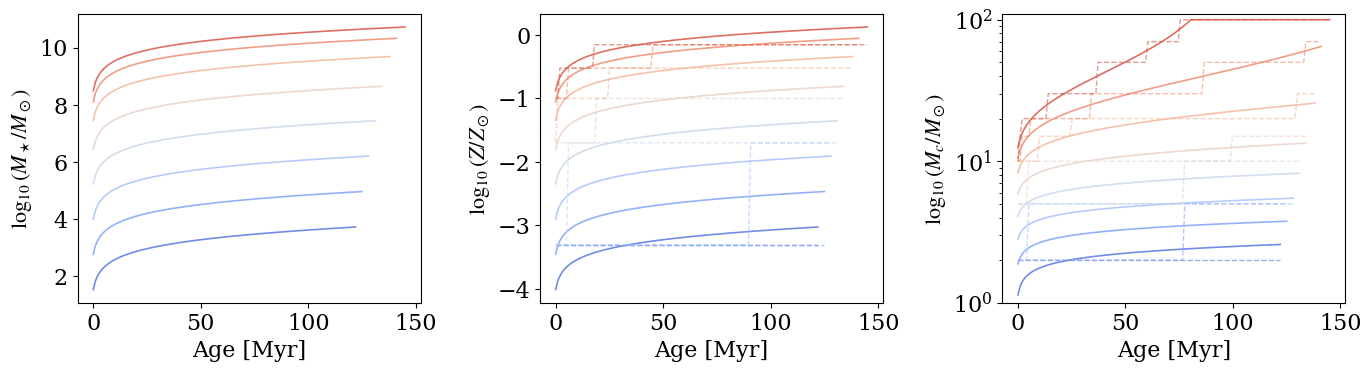

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

Zsun = 0.02 #Anders&Grevesse89, used in FIRE-2

sb99_Z = np.array([1e-5, 4e-4, 2e-3, 6e-3, 1.4e-2, 1])
Z_labels = ["1e-5", "4e-4", "2e-3", "6e-3", "1.4e-2", "1"]
sb99_Mc_by_Z = {
    "1e-5":  np.array([2, 5, 10]),
    "4e-4":  np.array([2, 5, 10, 15]),
    "2e-3":  np.array([5, 10, 15, 20, 30, 50]),
    "6e-3":  np.array([10, 20, 30, 50, 70, 100]),
    "1.4e-2": np.array([10, 20, 30, 50, 70, 100]),
    "1":     np.array([10, 20, 30, 50, 70, 100]),
}

for j, M in enumerate(Mstar_array):
    col = custom_colormap(float(j) / len(Mstar_array))
    label = f"$M_h={np.log10(Mh_array[j]):.1f}$"
    age = sb99_data_dict[M]["age"]

    Z_steps  = []
    mc_steps = []
    Z_steps_label = []
    mc_steps_label = []

    for mst_step in sb99_data_dict[M]["log_mst"]:
        Z_step  = stellar_mass_to_metallicity(model, mst_step)
        mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
        Z_steps.append(Z_step)
        mc_steps.append(mc_step)

        abs_Z = 10**(Z_step) *Zsun
        Z = Z_labels[np.argmin(np.abs(sb99_Z - abs_Z))] 
        sb99_Mc = sb99_Mc_by_Z[Z]     
        Mc = int(sb99_Mc[np.argmin(np.abs(sb99_Mc - mc_step))])

        Z_steps_label.append(np.log10(float(Z)/Zsun))
        mc_steps_label.append(Mc)


    axes[0].plot(age, sb99_data_dict[M]["log_mst"], color=col, lw=1.2, alpha=0.85, label=label)
    axes[1].plot(age, Z_steps,                      color=col, lw=1.2, alpha=0.85, label=label)
    axes[1].plot(age, Z_steps_label,                color=col, lw=1., alpha=0.6, label=label, linestyle="--")

    axes[2].plot(age, mc_steps,                     color=col, lw=1.2, alpha=0.85, label=label)
    axes[2].plot(age, mc_steps_label,               color=col, lw=1., alpha=0.6, label=label, linestyle="--")

axes[0].set_ylabel(r"$\log_{10}(M_\star/M_\odot)$")
axes[1].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")
axes[2].set_ylabel(r"$\log_{10}(M_c/M_\odot)$")
axes[2].set_ylim(1, 110)
axes[2].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Age [Myr]")
    #ax.legend(fontsize=9, framealpha=0.6)
   
plt.tight_layout()
plt.show()

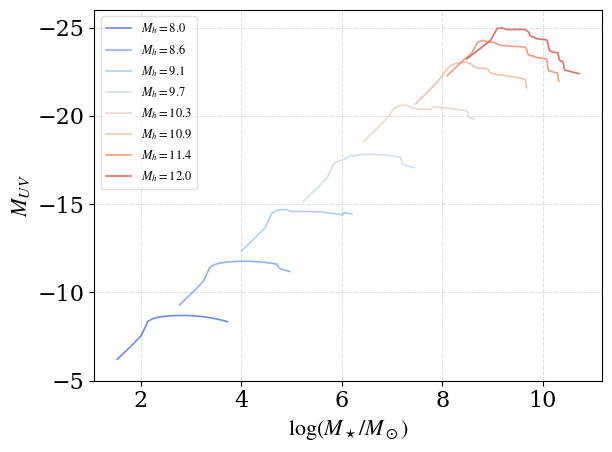

In [56]:
fig, ax = plt.subplots()
tstep = 1

for j in range(len(Mh_array)):
    col = custom_colormap(float(j) / len(Mh_array))
    Mstar = Mstar_array[j]
    
    sfh, log_mst_build, age = star_formation_history(Mh_array[j], redshift, tstep, epsilon[j])
    
    entry  = get_sb99_arrays(Mstar)
    tables = entry["tables"]
    
    l1500_arr = compute_l1500_steps_sb99_IMF(age=age, tstep=tstep, sfh=sfh, tables=tables)
    muv_arr   = l1500_to_muv_conv(l1500_arr)
    
    ax.plot(log_mst_build, muv_arr, color=col, lw=1.2, alpha=0.85, label=f"$M_h={np.log10(Mh_array[j]):.1f}$")

ax.set_xlabel(r"$\log(M_\star/M_\odot)$")
ax.set_ylabel(r"$M_{UV}$")
ax.legend(fontsize=9, framealpha=0.6)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(-5, -26)
plt.tight_layout()
plt.show()


Considero halo # ---> 0
Stays optically thin up to z=10

Considero halo # ---> 1
Stays optically thin up to z=10

Considero halo # ---> 2
Stays optically thin up to z=10

Considero halo # ---> 3
Stays optically thin up to z=10

Considero halo # ---> 4
time after which given halo is optically thick in the V-band --> 1.00 44.33
Corresponding to z= 11.657000621703071 redshift

Considero halo # ---> 5
time after which given halo is optically thick in the V-band --> 1.00 18.13
Corresponding to z= 12.369790698180038 redshift

Considero halo # ---> 6
time after which given halo is optically thick in the V-band --> 0.97 15.11
Corresponding to z= 12.524285383599999 redshift

Considero halo # ---> 7
time after which given halo is optically thick in the V-band --> 1.01 17.12
Corresponding to z= 12.57628350440597 redshift


 Saving fig1_galaxy_evolution.pdf


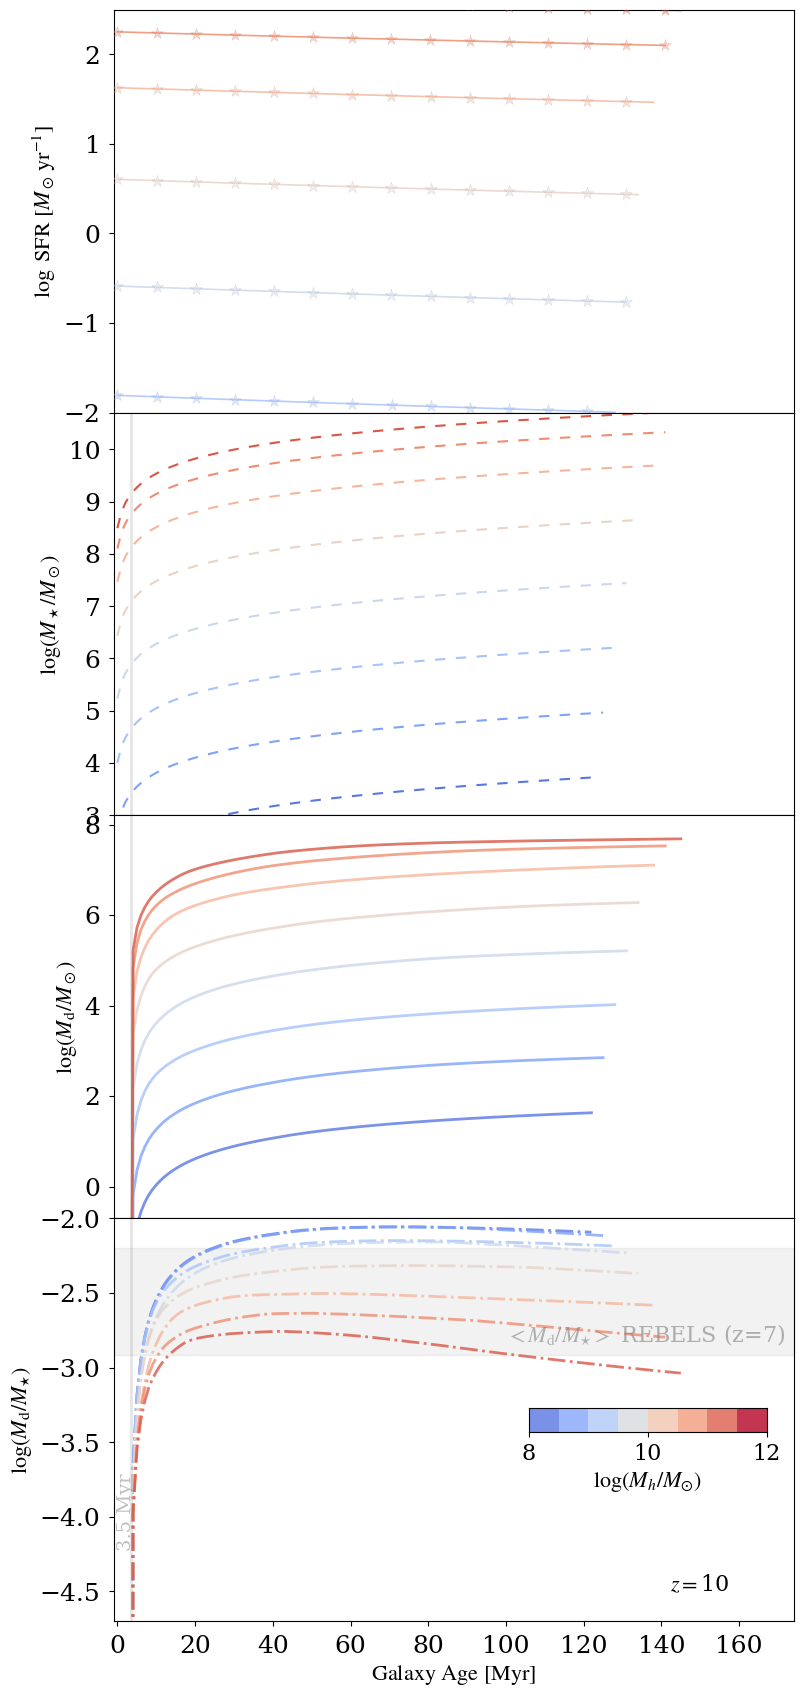

In [57]:

# Generate spin parameter distribution from GUREFT (Yung+23): lognormal
spin_param_distr = np.random.lognormal(mean=-3.6, sigma=0.5677, size=1000)

# Create 4-panel figure
fig, (ax_sfr, ax_mstar, ax_md, ax_ratio) = plt.subplots(4, 1, figsize=(8, 17), sharex=True)

plt.subplots_adjust(left=0.14, bottom=0.045, right=0.99, top=0.993, wspace=0.2, hspace=0.0)

age_ott = []

for j in range(len(Mh_array)):
    col = custom_colormap(float(j) / len(Mh_array))
    print("\nConsidero halo # --->", j)

    Mstar = Mstar_array[j]
    
    sfh, log_mst_build, age = star_formation_history(Mh_array[j], redshift, tstep, epsilon[j])

    # Get the full SFH-aware entry (list of per-step tables)
    entry = get_sb99_arrays(Mstar)
    tables = entry["tables"]  # list of dicts, one per SFH timestep

    # Compute derived quantities — pass the full table list instead of single arrays
    l1500_arr    = compute_l1500_steps_sb99_IMF(age=age, tstep=tstep, sfh=sfh, tables=tables)
    n_sn_arr, md_arr = compute_mdust_steps_IMF(age=age, tstep=tstep, sfh=sfh, tables=tables, yd=yd)
    dot_nion_arr = compute_dotnion_steps_IMF(age=age, tstep=tstep, sfh=sfh, tables=tables)

    
    # SFR panel: line + sparse star markers
    ax_sfr.plot(age, np.log10(sfh), color=col, lw=1.2, alpha=0.85, zorder=2)
    step = 10
    ax_sfr.scatter(
        age[::step],
        np.log10(sfh)[::step],
        marker="*",
        s=80,
        color=col,
        edgecolor="k",
        linewidth=0.1,
        alpha=0.4,
        zorder=3,
    )
    if j == 0:
        ax_sfr.set_ylabel(r"$\log\ \mathrm{SFR}\ [M_\odot\,\mathrm{yr}^{-1}]$")

    # Mstar panel
    ax_mstar.plot(age, log_mst_build, ls="--", lw=1.5, dashes=[5, 5], color=col)
    if j == 0:
        ax_mstar.set_ylabel(r"$\log (M_\star/M_\odot)$")

    # Md panel
    log_md = np.log10(md_arr)
    ax_md.plot(age, log_md, lw=2.0, alpha=0.8, color=col)
    if j == 0:
        ax_md.set_ylabel(r"$\log (M_{\rm d}/M_\odot)$")

    # Md /Mstar panel
    ratio = log_md - log_mst_build
    ax_ratio.plot(age, ratio, lw=2.0, ls="-.", alpha=0.8, color=col)

    # Calculate tau_V and optically thick transition
    tau_v = optical_depth(kv, md_arr, Mh_array[j], spin_param_distr.mean(), redshift)
    tau_v_max = optical_depth(kv, md_arr, Mh_array[j], np.percentile(spin_param_distr, 16), redshift)
    tau_v_min = optical_depth(kv, md_arr, Mh_array[j], np.percentile(spin_param_distr, 84), redshift)

    if tau_v[-1] >= 0.9:
        print(
            "time after which given halo is optically thick in the V-band --> "
            f"{tau_v[find_nearest(tau_v, 1.0)]:.2f} {age[find_nearest(tau_v, 1.0)]:.2f}",
        )

        # Compute redshift when galaxy was `age_thick` Myr old
        reds_thick = z_at_value(
            cosmo.age,
            (cosmo.age(redshift).value - (age[-1] - age[find_nearest(tau_v, 1.0)]) * const.Myr / const.Gyr)
            * cosmo.age(redshift).unit,
            method="bounded",
        )
        print("Corresponding to z=", reds_thick)
    else:
        print("Stays optically thin up to z=" + str(redshift))
        age_ott = np.append(age_ott, -999)

    # Save outputs
    header_text = (
        f"log(Mhalo/Msun) = {np.log10(Mh_array[j]):.3f}\n"
        f"yd = {yd}, epsilon_star = {epsilon[j]:.3f}, spin = {spin_param}\n"
        f"Columns: t[Myr]  SFR[Msun/yr]  log(Mstar/Msun)  log(Md/Msun)  "
        f"tau_v(MW dust)  tau_v_16th  tau_v_84th  L_1500[erg/s]"
    )

    

# Global formatting
for ax in (ax_sfr, ax_mstar, ax_md, ax_ratio):
    ax.tick_params(axis="both", which="major", labelsize=18, pad=6)

ax_sfr.set_ylim(-2, 2.5)
ax_mstar.set_ylim(3, 10.7)
ax_md.set_ylim(-0.7, 8.2)
ax_ratio.set_ylim(-4.7, -2)
ax_ratio.set_xlim(-1, 1.2 * age[-1])

# Labels and reference lines
ax_ratio.set_xlabel(r"$\mathrm{Galaxy\ Age\ [Myr]}$")
ax_ratio.set_ylabel(r"$\log (M_{\rm d}/M_{\star})$")
ax_ratio.text(0.98 * age[-1], -4.5, "$z=$" + str(int(redshift)))

for ax in (ax_mstar, ax_md, ax_ratio):
    ax.axvline(3.5, color="grey", lw=2.0, alpha=0.2)
ax_ratio.text(0.0, -4.2, "3.5 Myr", rotation=90, fontsize=14, color="grey", alpha=0.5)

# REBELS Md/Mstar region
ax_ratio.axhspan(
    np.percentile(rebels["log_Md"] - rebels["log_Mstar"], 16),
    np.percentile(rebels["log_Md"] - rebels["log_Mstar"], 84),
    color="grey",
    alpha=0.1,
)
ax_ratio.text(100, np.log10(0.0015), r"$< M_{\rm d}/M_{\star}>$ REBELS (z=7)", fontsize=16, color="grey", alpha=0.6)

# Colorbar
bar = np.zeros((1, len(Mh_array)))
bar[0][:] = np.linspace(np.log10(Mh_array).min(), np.log10(Mh_array).max(), len(Mh_array))
cbaxis = inset_axes(ax_ratio, width="35%", height="6%", loc="center right", borderpad=1.2)
ext = (np.log10(Mh_array).min(), np.log10(Mh_array).max(), 0.0, 0.8)
cbaxis.imshow(
    bar,
    cmap=custom_colormap,
    extent=ext,
    aspect="auto",
    vmin=np.log10(Mh_array).min(),
    vmax=np.log10(Mh_array).max(),
    alpha=0.8,
)
cbaxis.set_xlabel(r"$\log (M_{h}/M_{\odot})$")
cbaxis.tick_params(axis="both", which="major", pad=4)
cbaxis.set_yticks([])

print("\n\n Saving fig1_galaxy_evolution.pdf")
fig.savefig(OUTPUT_DIR / "fig1_galaxy_evolution.pdf", bbox_inches="tight")
plt.show()

### 5 - Plots to compare different models and parameters

In [94]:
tstep = 1
redshift = 7

yd_att = 0.01

spin_param_distr = np.random.lognormal(mean=-3.6, sigma=0.5677, size=1000)
spin_param_mean = spin_param_distr.mean()

param_combinations = [
    {"model": "SC",    "SN_max_mass": 20,  "linestyle": "--", "color": "orangered",   "alpha": 0.6},
    {"model": "SC",    "SN_max_mass": 100, "linestyle": "-",  "color": "orangered",   "alpha": 1.0},
    {"model": "FIRE2", "SN_max_mass": 20,  "linestyle": "--", "color": "forestgreen", "alpha": 0.6},
    {"model": "FIRE2", "SN_max_mass": 100, "linestyle": "-",  "color": "forestgreen", "alpha": 1.0},
]

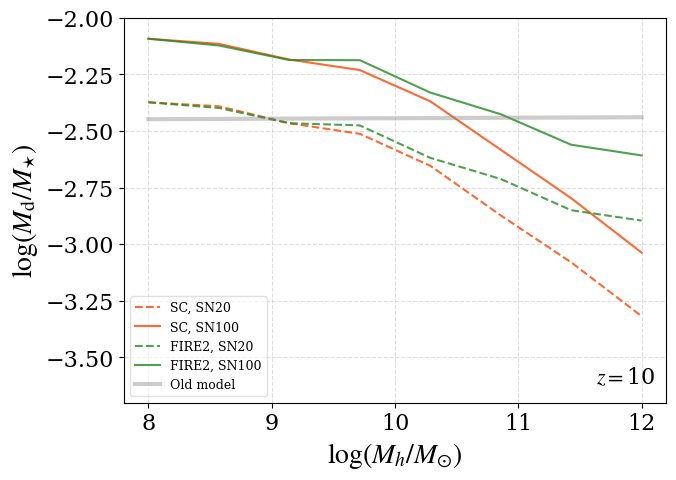

In [59]:
fig, ax_ratio = plt.subplots(figsize=(7, 5))

for params in param_combinations:
    _model      = params["model"]
    SN_max_mass = params["SN_max_mass"]
    _ls         = params["linestyle"]
    _color      = params["color"]
    _sb99_cache.clear()

    final_ratios = []

    for j, Mh in enumerate(Mh_array):
        eps   = evolving_SFE(np.array([Mh]), redshift)[0]
        Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]

        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

        timestep_tables = []
        for mst_step in log_mst_build:
            Z_step  = stellar_mass_to_metallicity(_model, mst_step)
            mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
            timestep_tables.append(_load_sb99_table(Z_step, mc_step))

        _, md_arr = compute_mdust_steps_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables, yd=yd
        )

        final_ratios.append(np.log10(md_arr[-1]) - log_mst_build[-1])

    label = f"{_model}, SN{SN_max_mass}"
    ax_ratio.plot(np.log10(Mh_array), final_ratios, lw=1.5, ls=_ls, color=_color, label=label, alpha=0.8)

old_final_ratios = []

for j, Mh in enumerate(Mh_array):
    eps   = 0.1
    Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]

    sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

    _, md_arr = compute_mdust_steps(
        age=age, tstep=tstep, sfh=sfh,
        time_yr=time_yr, log_snr_yr=log_snr_yr, yd=yd   # old-style single arrays
    )

    old_final_ratios.append(np.log10(md_arr[-1]) - log_mst_build[-1])

ax_ratio.plot(np.log10(Mh_array), old_final_ratios,
              lw=3, color="grey", alpha=0.4, label="Old model")


ax_ratio.set_xlabel(r"$\log (M_{h}/M_{\odot})$", fontsize=20)
ax_ratio.set_ylabel(r"$\log (M_{\rm d}/M_{\star})$", fontsize=20)
ax_ratio.set_ylim(-3.7, -2)
ax_ratio.grid(True, linestyle="--", alpha=0.4)
ax_ratio.legend(fontsize=9, framealpha=0.6, loc="lower left")
ax_ratio.text(0.98, 0.05, "$z=$" + str(int(redshift)),
              transform=ax_ratio.transAxes, ha="right")
plt.show()

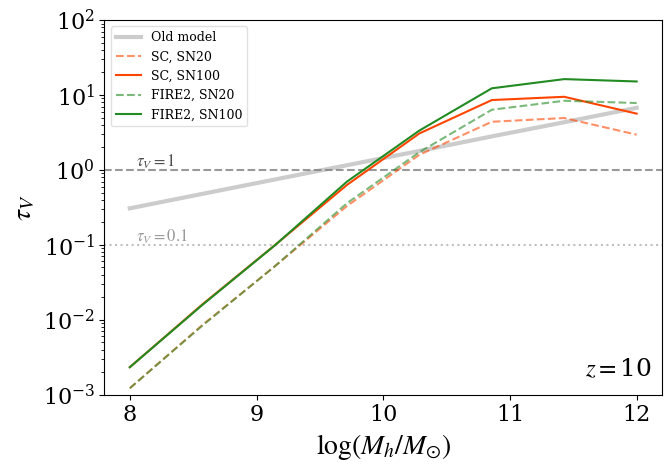

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))

old_final_tau = []

for j, Mh in enumerate(Mh_array):
    eps = 0.1
    sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)
    _, md_arr = compute_mdust_steps(
        age=age, tstep=tstep, sfh=sfh,
        time_yr=time_yr, log_snr_yr=log_snr_yr, yd=yd
    )
    tau_v = optical_depth(kv, md_arr, Mh, spin_param_mean, redshift)
    old_final_tau.append(tau_v[-1])

ax.plot(np.log10(Mh_array), old_final_tau,
        lw=3, color="grey", alpha=0.4, label="Old model")

for params in param_combinations:
    _model      = params["model"]
    SN_max_mass = params["SN_max_mass"]
    _ls         = params["linestyle"]
    _color      = params["color"]
    _alpha      = params["alpha"]
    _sb99_cache.clear()

    final_tau = []

    for j, Mh in enumerate(Mh_array):
        eps = evolving_SFE(np.array([Mh]), redshift)[0]
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

        timestep_tables = []
        for mst_step in log_mst_build:
            Z_step  = stellar_mass_to_metallicity(_model, mst_step)
            mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
            timestep_tables.append(_load_sb99_table(Z_step, mc_step))

        _, md_arr = compute_mdust_steps_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables, yd=yd
        )
        tau_v = optical_depth(kv, md_arr, Mh, spin_param_mean, redshift)
        final_tau.append(tau_v[-1])

    label = f"{_model}, SN{SN_max_mass}"
    ax.plot(np.log10(Mh_array), final_tau,
            lw=1.5, ls=_ls, color=_color, alpha=_alpha, label=label)


ax.axhline(0.1, ls=":", color="black", alpha=0.25, zorder=-1000)
ax.text(8.05, 0.11, r"$\tau_V=0.1$", color="black", alpha=0.4, fontsize=12)
ax.axhline(1.0, ls="--", color="black", alpha=0.4, zorder=-1000)
ax.text(8.05, 1.1, r"$\tau_V=1$", color="black", alpha=0.7, fontsize=12)

ax.set_yscale("log")
ax.set_xlabel(r"$\log (M_{h}/M_{\odot})$", fontsize=20)
ax.set_ylabel(r"$\tau_V$", fontsize=20)
#ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=9, framealpha=0.6, loc="upper left")
ax.text(0.98, 0.05, "$z=$" + str(int(redshift)),
        transform=ax.transAxes, ha="right", fontsize=18)
ax.set_ylim(0.001, 100)
plt.tight_layout()
plt.show()

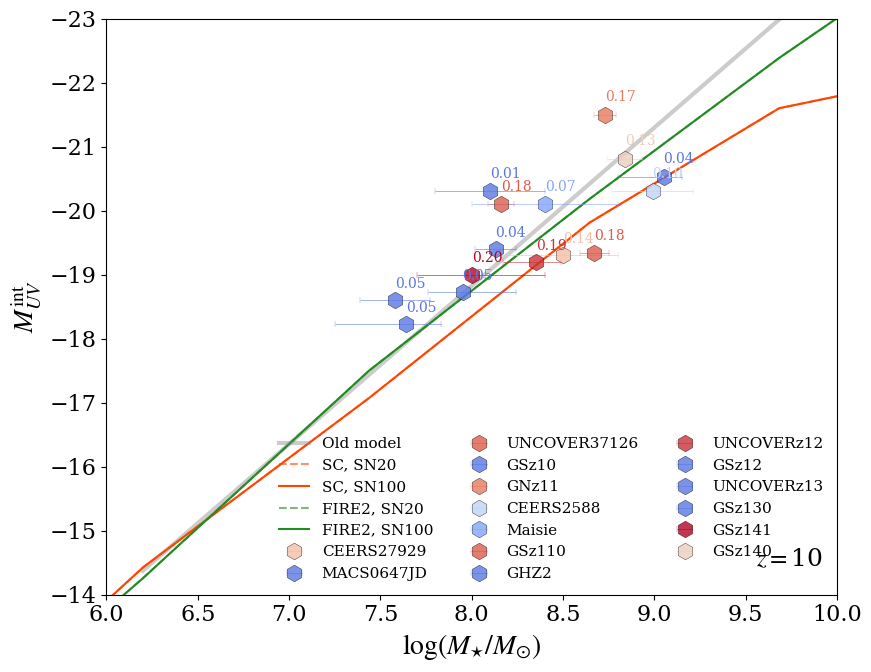

In [91]:
fig, ax = plt.subplots(figsize=(9, 7))

old_log_mstar = []
old_muv       = []

for Mh in Mh_array:
    eps   = 0.1
    Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]
    sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

    l1500 = compute_l1500_steps(
        l1500=l1500_sb99, age=age, tstep=tstep, sfh=sfh,
        time_yr_l1500=time_yr_l1500, method="SB99"
    )
    old_log_mstar.append(np.log10(Mstar))
    old_muv.append(l1500_to_muv_conv(l1500[-1]))

ax.plot(old_log_mstar, old_muv,
        lw=3, color="grey", alpha=0.4, label="Old model")

for params in param_combinations:
    _model      = params["model"]
    SN_max_mass = params["SN_max_mass"]
    _ls         = params["linestyle"]
    _color      = params["color"]
    _alpha      = params["alpha"]
    _sb99_cache.clear()

    log_mstar_arr = []
    muv_arr       = []

    for Mh in Mh_array:
        eps   = evolving_SFE(np.array([Mh]), redshift)[0]
        Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

        timestep_tables = []
        for mst_step in log_mst_build:
            Z_step  = stellar_mass_to_metallicity(_model, mst_step)
            mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
            timestep_tables.append(_load_sb99_table(Z_step, mc_step))

        l1500 = compute_l1500_steps_sb99_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables
        )
        log_mstar_arr.append(np.log10(Mstar))
        muv_arr.append(l1500_to_muv_conv(l1500[-1]))

        #peak_idx = np.argmax(l1500)
        #muv_arr.append(l1500_to_muv_conv(l1500[peak_idx]))



    label = f"{_model}, SN{SN_max_mass}"
    ax.plot(log_mstar_arr, muv_arr,
            lw=1.5, ls=_ls, color=_color, alpha=_alpha, label=label)

if redshift >= 10:
    jwst_plot = jwst[
        (jwst["log_Mstar"] > 0)
        & np.isfinite(jwst["MUV"])
        & np.isfinite(jwst["err_logMstar_low"])
        & np.isfinite(jwst["err_logMstar_high"])
        & np.isfinite(jwst["tau_v"])
    ].copy()

    tau_span = jwst_plot["tau_v"].max() - 0.05
    if not np.isfinite(tau_span) or tau_span <= 0:
        tau_span = 1.0

    for _, row in jwst_plot.iterrows():
        point_color = custom_colormap((row["tau_v"] - 0.05) / tau_span)
        ax.errorbar(
            row["log_Mstar"], row["MUV"],
            xerr=[[abs(row["err_logMstar_low"])], [abs(row["err_logMstar_high"])]],
            label=row["name"], ms=12.0, marker="h", capsize=2.5,
            elinewidth=0.5, mec="black", alpha=0.8, mew=0.3,
            ls="none", color=point_color,
        )
        if row["tau_v"] > 0:
            ax.text(row["log_Mstar"], 1.01 * row["MUV"],
                    f"{row['tau_v']:.2f}", fontsize=10, color=point_color)

if redshift == 7:
    for _, row in rebels.iterrows():
        ax.errorbar(
            row["log_Mstar"], row["MUV"],
            xerr=[[row["err_log_Mstar_low"]], [row["err_log_Mstar_high"]]],
            label="REB-" + str(int(row["id"])), ms=12.0, marker="s",
            capsize=2.5, mec="black", elinewidth=0.5, alpha=0.8, mew=0.3,
            ls="none",
            color=custom_colormap(
                (row["Av"] - 0.05 * 1.086) / (rebels["Av"].max() - 0.05 * 1.086)
            ),
        )

ax.set_ylabel(r"$M_{UV}^{\rm int}$", fontsize=20)
ax.set_xlabel(r"$\log (M_{\star}/M_{\odot})$", fontsize=20)
ax.set_ylim(-14,  -23)
ax.set_xlim(6, 10)
ax.legend(fontsize=11, loc="lower right", ncols=3, frameon=False)
ax.text(0.98, 0.05, "$z=$" + str(int(redshift)),
        transform=ax.transAxes, ha="right", fontsize=18)
plt.tight_layout()
plt.show()

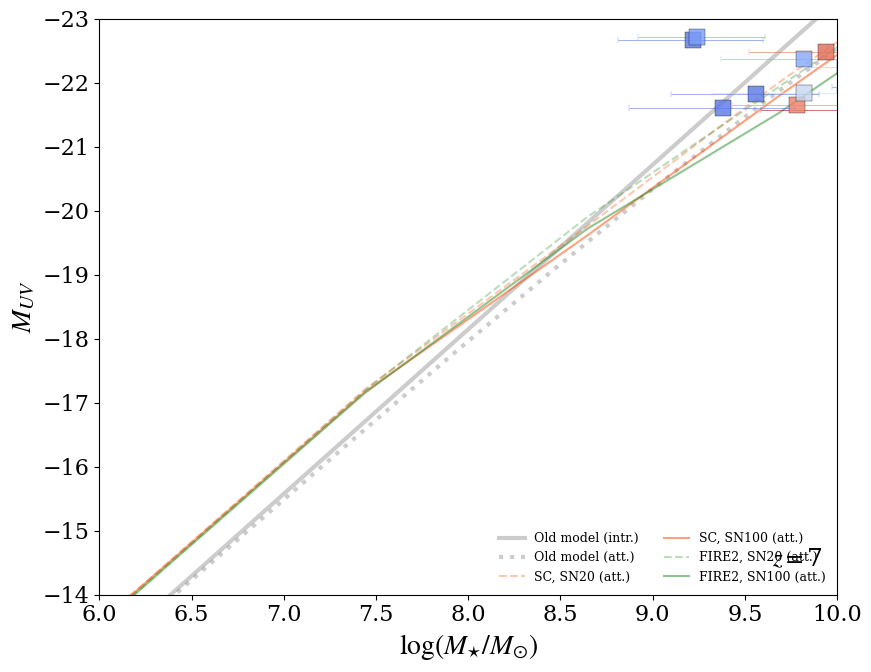

In [95]:
# choosing peak luminosity instead of last 

fig, ax = plt.subplots(figsize=(9, 7))

old_log_mstar, old_muv_intr, old_muv_att = [], [], []

for Mh in Mh_array:
    eps = 0.1
    Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]
    sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

    l1500 = compute_l1500_steps(
        l1500=l1500_sb99, age=age, tstep=tstep, sfh=sfh,
        time_yr_l1500=time_yr_l1500, method="SB99"
    )
    _, md_arr = compute_mdust_steps(
        age=age, tstep=tstep, sfh=sfh,
        time_yr=time_yr, log_snr_yr=log_snr_yr, yd=yd_att
    )
    tau_uv = optical_depth(kuv, md_arr[-1], Mh, spin_param_distr, redshift)
    luv    = np.median(np.atleast_1d(transmission_sphere_mixed(tau_uv)) * l1500[-1])

    old_log_mstar.append(np.log10(Mstar))
    old_muv_intr.append(l1500_to_muv_conv(l1500[-1]))
    old_muv_att.append(l1500_to_muv_conv(luv))

ax.plot(old_log_mstar, old_muv_intr, lw=3, color="grey", alpha=0.4, label="Old model (intr.)")
ax.plot(old_log_mstar, old_muv_att,  lw=3, color="grey", alpha=0.4, ls=":", label="Old model (att.)")

for params in param_combinations:
    _model      = params["model"]
    SN_max_mass = params["SN_max_mass"]
    _ls         = params["linestyle"]
    _color      = params["color"]
    _alpha      = params["alpha"]
    _sb99_cache.clear()

    log_mstar_arr, muv_intr_arr, muv_att_arr = [], [], []

    for Mh in Mh_array:
        eps   = evolving_SFE(np.array([Mh]), redshift)[0]
        Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

        timestep_tables = []
        for mst_step in log_mst_build:
            Z_step  = stellar_mass_to_metallicity(_model, mst_step)
            mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
            timestep_tables.append(_load_sb99_table(Z_step, mc_step))

        l1500 = compute_l1500_steps_sb99_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables
        )
        _, md_arr = compute_mdust_steps_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables, yd=yd_att
        )

        peak_idx = np.argmax(l1500)

        tau_uv = optical_depth(kuv, md_arr[-1], Mh, spin_param_distr, redshift)
        #luv    = np.median(np.atleast_1d(transmission_sphere_mixed(tau_uv)) * l1500[-1])
        luv    = np.median(np.atleast_1d(transmission_sphere_mixed(tau_uv)) * l1500[peak_idx])

        log_mstar_arr.append(np.log10(Mstar))
        #muv_intr_arr.append(l1500_to_muv_conv(l1500[-1]))

        muv_intr_arr.append(l1500_to_muv_conv(l1500[peak_idx]))
        muv_att_arr.append(l1500_to_muv_conv(luv))

    label = f"{_model}, SN{SN_max_mass}"
    #ax.plot(log_mstar_arr, muv_intr_arr,
            #lw=1.5, ls=_ls, color=_color, alpha=_alpha, label=f"{label} (intr.)")
    ax.plot(log_mstar_arr, muv_att_arr,
            lw=1.5, ls=_ls, color=_color, alpha=_alpha * 0.5, label=f"{label} (att.)")

if redshift >= 10:
    jwst_plot = jwst[
        (jwst["log_Mstar"] > 0)
        & np.isfinite(jwst["MUV"])
        & np.isfinite(jwst["err_logMstar_low"])
        & np.isfinite(jwst["err_logMstar_high"])
        & np.isfinite(jwst["tau_v"])
    ].copy()

    tau_span = jwst_plot["tau_v"].max() - 0.05
    if not np.isfinite(tau_span) or tau_span <= 0:
        tau_span = 1.0

    for _, row in jwst_plot.iterrows():
        point_color = custom_colormap((row["tau_v"] - 0.05) / tau_span)
        ax.errorbar(
            row["log_Mstar"], row["MUV"],
            xerr=[[abs(row["err_logMstar_low"])], [abs(row["err_logMstar_high"])]],
             ms=12.0, marker="h", capsize=2.5,
            elinewidth=0.5, mec="black", alpha=0.8, mew=0.3,
            ls="none", color=point_color,
        )
        if row["tau_v"] > 0:
            ax.text(row["log_Mstar"], 1.01 * row["MUV"],
                    f"{row['tau_v']:.2f}", fontsize=10, color=point_color)

if redshift == 7:
    for _, row in rebels.iterrows():
        ax.errorbar(
            row["log_Mstar"], row["MUV"],
            xerr=[[row["err_log_Mstar_low"]], [row["err_log_Mstar_high"]]],
            ms=12.0, marker="s",
            capsize=2.5, mec="black", elinewidth=0.5, alpha=0.8, mew=0.3,
            ls="none",
            color=custom_colormap(
                (row["Av"] - 0.05 * 1.086) / (rebels["Av"].max() - 0.05 * 1.086)
            ),
        )

ax.set_ylabel(r"$M_{UV}$", fontsize=20)
ax.set_xlabel(r"$\log (M_{\star}/M_{\odot})$", fontsize=20)
ax.set_ylim(-14, -23)
ax.set_xlim(6, 10)
ax.legend(fontsize=9, loc="lower right", ncols=2, frameon=False)
ax.text(0.98, 0.05, "$z=$" + str(int(redshift)),
        transform=ax.transAxes, ha="right", fontsize=18)
plt.tight_layout()
plt.show()

In [80]:
jwst_uv = pd.read_csv(DATA_DIR / "uv_lf_observations.csv", comment="#")
phi_data_jwst = jwst_uv["phi"]
redshift_jwst = jwst_uv["redshift"]
UV_data = jwst_uv["muv"]

halo_mass_jwst = np.array([log_halo_mass_function_inv(np.array([phi]), z,)[0]
 for phi, z in zip(phi_data_jwst, redshift_jwst)])

print(halo_mass_jwst)

[11.02970829 11.02690214 10.76967288 10.49413996 10.94992432 10.93534115
 11.33001208 11.08453613 10.90815592 10.80722875 10.71098511 10.58169219
 10.46999973 11.33001208 11.04456044 10.81359882 10.55907398 10.28903185
 11.4298677  11.4889561  11.21635137 11.05256989 10.79599826 10.59656932
 11.27135481 11.02620868 10.75513311 10.60151652 10.47175448 10.3400859
 10.18016747 10.93016731 10.89624387 10.72365623 10.62299202 10.59057744
 10.50235737 10.35244129 10.70825895 10.55864077 10.5097892  10.38476659
 10.32234719 11.05421074 11.01711635 10.37711106 10.31415912 10.19106106
  9.92417827 10.80581435 10.62299202 10.30689441 10.16026013 10.4402164
 10.2912215  10.40513688 10.67936639 10.26358297 10.1217485  10.31192524
 10.53248675 10.55505924 10.44602398 10.23579474 10.05007301 10.21577716
  9.9362991  10.11177813]


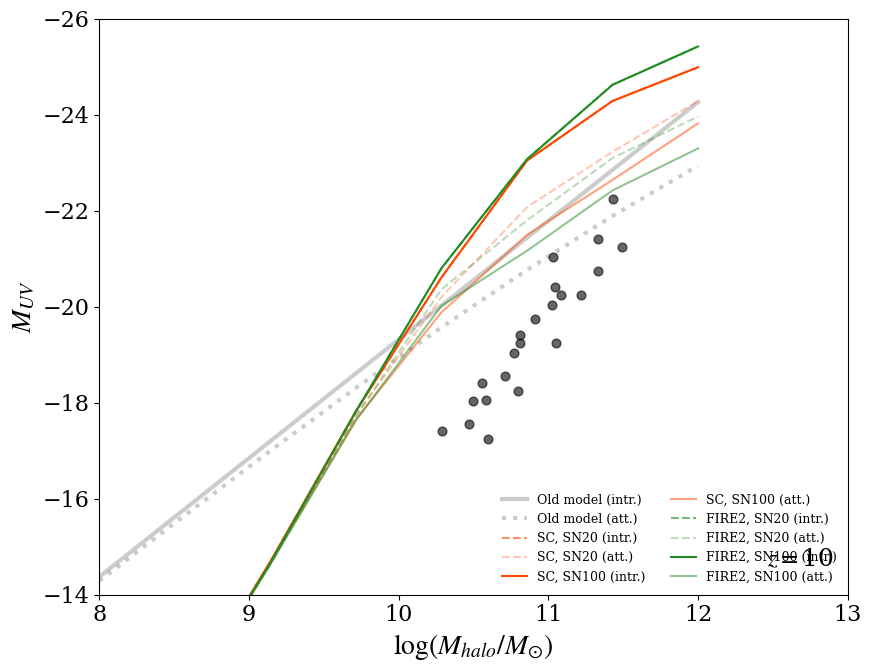

In [64]:
# versus halo mass

fig, ax = plt.subplots(figsize=(9, 7))

old_log_mhalo, old_muv_intr, old_muv_att = [], [], []

for Mh in Mh_array:
    eps = 0.1
    Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]
    sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

    l1500 = compute_l1500_steps(
        l1500=l1500_sb99, age=age, tstep=tstep, sfh=sfh,
        time_yr_l1500=time_yr_l1500, method="SB99"
    )
    _, md_arr = compute_mdust_steps(
        age=age, tstep=tstep, sfh=sfh,
        time_yr=time_yr, log_snr_yr=log_snr_yr, yd=yd_att
    )
    tau_uv = optical_depth(kuv, md_arr[-1], Mh, spin_param_distr, redshift)
    luv    = np.median(np.atleast_1d(transmission_sphere_mixed(tau_uv)) * l1500[-1])

    old_log_mhalo.append(np.log10(Mh))
    old_muv_intr.append(l1500_to_muv_conv(l1500[-1]))
    old_muv_att.append(l1500_to_muv_conv(luv))

ax.plot(old_log_mhalo, old_muv_intr, lw=3, color="grey", alpha=0.4, label="Old model (intr.)")
ax.plot(old_log_mhalo, old_muv_att,  lw=3, color="grey", alpha=0.4, ls=":", label="Old model (att.)")

for params in param_combinations:
    _model      = params["model"]
    SN_max_mass = params["SN_max_mass"]
    _ls         = params["linestyle"]
    _color      = params["color"]
    _alpha      = params["alpha"]
    _sb99_cache.clear()

    log_mhalo_arr, muv_intr_arr, muv_att_arr = [], [], []

    for Mh in Mh_array:
        eps   = evolving_SFE(np.array([Mh]), redshift)[0]
        Mstar = halo_to_stellar_mass(np.array([Mh]), fb, np.array([eps]))[0]
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

        timestep_tables = []
        for mst_step in log_mst_build:
            Z_step  = stellar_mass_to_metallicity(_model, mst_step)
            mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
            timestep_tables.append(_load_sb99_table(Z_step, mc_step))

        l1500 = compute_l1500_steps_sb99_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables
        )
        _, md_arr = compute_mdust_steps_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables, yd=yd_att
        )

        peak_idx = np.argmax(l1500)

        tau_uv = optical_depth(kuv, md_arr[-1], Mh, spin_param_distr, redshift)
        #luv    = np.median(np.atleast_1d(transmission_sphere_mixed(tau_uv)) * l1500[-1])
        luv    = np.median(np.atleast_1d(transmission_sphere_mixed(tau_uv)) * l1500[peak_idx])

        log_mhalo_arr.append(np.log10(Mh))
        #muv_intr_arr.append(l1500_to_muv_conv(l1500[-1]))

        muv_intr_arr.append(l1500_to_muv_conv(l1500[peak_idx]))
        muv_att_arr.append(l1500_to_muv_conv(luv))

    label = f"{_model}, SN{SN_max_mass}"
    ax.plot(log_mhalo_arr, muv_intr_arr,
            lw=1.5, ls=_ls, color=_color, alpha=_alpha, label=f"{label} (intr.)")
    ax.plot(log_mhalo_arr, muv_att_arr,
            lw=1.5, ls=_ls, color=_color, alpha=_alpha * 0.5, label=f"{label} (att.)")

if redshift >= 10:
    jwst_uv["log_Mh"] = halo_mass_jwst

    jwst_z = jwst_uv[
        (jwst_uv["redshift"] == redshift)
        & np.isfinite(jwst_uv["log_Mh"])
        & (jwst_uv["is_upper_limit"] == 0)  # detections only
    ].copy()

    for _, row in jwst_z.iterrows():
        ax.scatter(
            row["log_Mh"], row["muv"],
            s=40, marker="o", color="black", alpha=0.6, zorder=5,
        )

if redshift == 7:
    for _, row in rebels.iterrows():
        ax.errorbar(
            row["log_Mstar"], row["MUV"],
            xerr=[[row["err_log_Mstar_low"]], [row["err_log_Mstar_high"]]],
            ms=12.0, marker="s",
            capsize=2.5, mec="black", elinewidth=0.5, alpha=0.8, mew=0.3,
            ls="none",
            color=custom_colormap(
                (row["Av"] - 0.05 * 1.086) / (rebels["Av"].max() - 0.05 * 1.086)
            ),
        )

ax.set_ylabel(r"$M_{UV}$", fontsize=20)
ax.set_xlabel(r"$\log (M_{halo}/M_{\odot})$", fontsize=20)
ax.set_ylim(-14, -26)
ax.set_xlim(8, 13)
ax.legend(fontsize=9, loc="lower right", ncols=2, frameon=False)
ax.text(0.98, 0.05, "$z=$" + str(int(redshift)),
        transform=ax.transAxes, ha="right", fontsize=18)
plt.tight_layout()
plt.show()

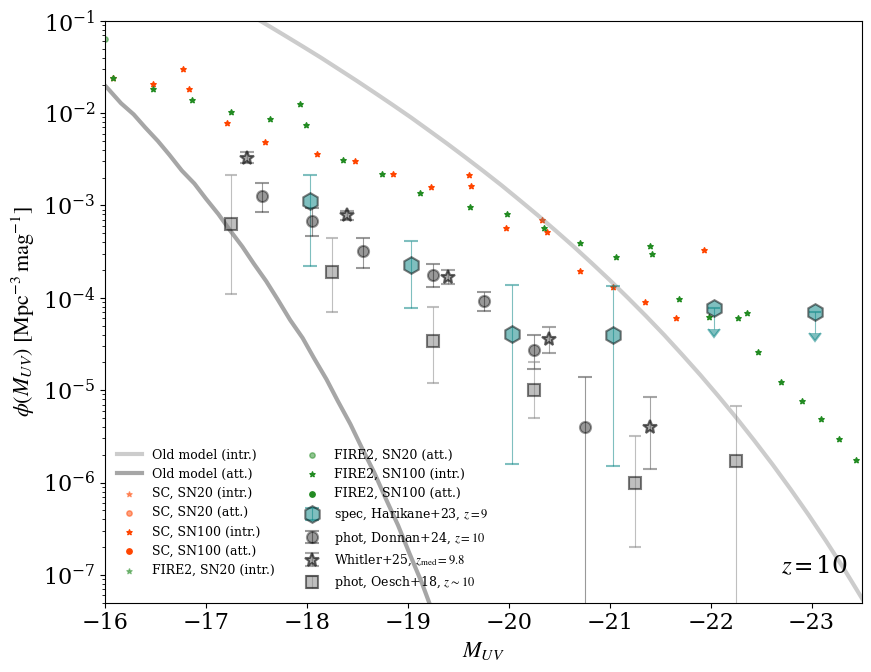

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
tstep = 1
yd_lf = 0.02

K_SPINS = 7
W_BLEND = 0.6
mu_ln, sig_ln = np.log(10**-1.5677), 0.5390
u = (np.arange(1, K_SPINS + 1) - 0.5) / K_SPINS
spin_quant = np.exp(mu_ln + sig_ln * norm.ppf(u))

log_mh_array = np.linspace(8, 13, 70)
Mh_grid      = 10**log_mh_array
dn_dlog_m    = log_halo_mass_function(log_mh_array, redshift)

param_combinations = [
    {"model": "SC",    "SN_max_mass": 20,   "color": "orangered",   "alpha": 0.5},
    {"model": "SC",    "SN_max_mass": 100,   "color": "orangered",   "alpha": 1.0},
    {"model": "FIRE2", "SN_max_mass": 20,   "color": "forestgreen", "alpha": 0.5},
    {"model": "FIRE2", "SN_max_mass": 100,  "color": "forestgreen", "alpha": 1.0},
]

L1500_old = np.empty_like(log_mh_array, float)
Md1_old   = np.empty_like(log_mh_array, float)

for j, Mh in enumerate(Mh_grid):
    eps = 0.1
    sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)
    L1500_old[j] = compute_l1500_steps(l1500_sb99, age, tstep, sfh, time_yr_l1500)[-1]
    Md1_old[j]   = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd=1.0)[1][-1]

Md_old  = yd_lf * Md1_old
MUV_old = l1500_to_muv_conv(L1500_old)

T_eff_old = np.empty_like(Mh_grid, float)
for j, Mh in enumerate(Mh_grid):
    tau_k = optical_depth(kuv, Md_old[j], Mh, spin_quant, redshift)
    TK    = transmission_sphere_mixed(tau_k)
    T_eff_old[j] = (1 - W_BLEND) * np.median(TK) + W_BLEND * np.mean(TK)

MUV_att_old = l1500_to_muv_conv(T_eff_old * L1500_old)

for MUV_plot, alpha, label in [
    (MUV_old,     0.4, "Old model (intr.)"),
    (MUV_att_old, 0.7, "Old model (att.)"),
]:
    dmuv = np.gradient(MUV_plot, log_mh_array)
    dmuv = np.where(np.abs(dmuv) < 1e-6, np.sign(dmuv) * 1e-6, dmuv)
    phi  = dn_dlog_m / np.abs(dmuv)
    MUV_plot, phi = enforce_monotonic(MUV_plot, phi, direction="decreasing")
    phi  = np.where(np.isfinite(phi) & (phi > 0), phi, np.nan)
    ax.plot(MUV_plot, phi, lw=3, ls="-", color="grey", alpha=alpha, label=label)

for params in param_combinations:
    _model      = params["model"]
    SN_max_mass = params["SN_max_mass"]
    #_ls         = params["linestyle"]
    _color      = params["color"]
    _alpha      = params["alpha"]
    _sb99_cache.clear()

    L1500_grid = np.empty_like(log_mh_array, float)
    Md1_grid   = np.empty_like(log_mh_array, float)

    for j, Mh in enumerate(Mh_grid):
        eps = evolving_SFE(np.array([Mh]), redshift)[0]
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, eps)

        timestep_tables = []
        for mst_step in log_mst_build:
            Z_step  = stellar_mass_to_metallicity(_model, mst_step)
            mc_step = mc_evolving_IMF(redshift, Z_step, imf_min_mass, imf_max_mass)
            timestep_tables.append(_load_sb99_table(Z_step, mc_step))

        L1500_grid[j] = compute_l1500_steps_sb99_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables
        )[-1]
        Md1_grid[j] = compute_mdust_steps_IMF(
            age=age, tstep=tstep, sfh=sfh, tables=timestep_tables, yd=1.0
        )[1][-1]

    Md_grid  = yd_lf * Md1_grid
    MUV_intr = l1500_to_muv_conv(L1500_grid)

    T_eff = np.empty_like(Mh_grid, float)
    for j, Mh in enumerate(Mh_grid):
        tau_k    = optical_depth(kuv, Md_grid[j], Mh, spin_quant, redshift)
        TK       = transmission_sphere_mixed(tau_k)
        T_eff[j] = (1 - W_BLEND) * np.median(TK) + W_BLEND * np.mean(TK)

    MUV_att = l1500_to_muv_conv(T_eff * L1500_grid)

    label = f"{_model}, SN{SN_max_mass}"

    for MUV_plot, marker, label_suffix in [
        (MUV_intr, '*', " (intr.)"),
        (MUV_att,  'o', " (att.)"),
    ]:
        
        dmuv = np.gradient(MUV_plot, log_mh_array)
        dmuv = np.where(np.abs(dmuv) < 1e-6, np.sign(dmuv) * 1e-6, dmuv)
        phi  = dn_dlog_m / np.abs(dmuv)
        MUV_plot, phi = enforce_monotonic(MUV_plot, phi, direction="decreasing")
        phi  = np.where(np.isfinite(phi) & (phi > 0), phi, np.nan)
        ax.scatter(MUV_plot, phi, s=15,
                 color=_color, marker=marker, alpha=_alpha,
                label=label + label_suffix)

# ── Observational data ─────────────────────────────────────────────────────
plot_lf_data(redshift, ax=ax)

ax.set_yscale("log")
ax.set_ylabel(r"$\phi(M_{UV})\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$", fontsize=16)
ax.set_xlabel(r"$M_{UV}$", fontsize=16)
ax.set_xlim(-16, -23.5)
ax.set_ylim(0.5e-7, 1e-1)
ax.legend(fontsize=9, ncols=2, loc="lower left", frameon=False)
ax.text(0.98, 0.05, "$z=$" + str(int(redshift)),
        transform=ax.transAxes, ha="right", fontsize=18)
plt.tight_layout()
plt.show()